In [2]:
!pip install torch torchvision torchaudio
!pip install numpy pandas scikit-learn tqdm

   ---------------------------------------- 0.0/241.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/241.4 MB ? eta -:--:--
   ---------------------------------------- 0.5/241.4 MB 932.9 kB/s eta 0:04:19
   ---------------------------------------- 0.5/241.4 MB 932.9 kB/s eta 0:04:19
   ---------------------------------------- 0.8/241.4 MB 882.6 kB/s eta 0:04:33
   ---------------------------------------- 1.0/241.4 MB 986.7 kB/s eta 0:04:04
   ---------------------------------------- 1.0/241.4 MB 986.7 kB/s eta 0:04:04
   ---------------------------------------- 1.3/241.4 MB 860.2 kB/s eta 0:04:40
   ---------------------------------------- 1.6/241.4 MB 806.6 kB/s eta 0:04:58
   ---------------------------------------- 1.6/241.4 MB 806.6 kB/s eta 0:04:58
   ---------------------------------------- 1.6/241.4 MB 806.6 kB/s eta 0:04:58
   ---------------------------------------- 1.8/241.4 MB 745.8 kB/s eta 0:05:22
   ---------------------------------------- 2.1/241.4 MB 8

In [4]:
!git clone https://github.com/sailorlee97/FlowGANAnomaly.git
!cd FlowGANAnomaly

Cloning into 'FlowGANAnomaly'...


In [8]:
import pandas as pd

df = pd.read_csv("D:/AISA_Miniproject/CSV files/Monday-WorkingHours.pcap_ISCX.csv", low_memory=False)
print(df.columns.tolist())

[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag 

In [6]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

RAW_DATA_DIR = "D:\\AISA_Miniproject\\FlowGANAnomaly\\cicids2017"
OUTPUT_DIR = "D:\\AISA_Miniproject\\FlowGANAnomaly\\prepared"

def load_and_merge_csv():
    if not os.path.exists(RAW_DATA_DIR):
        raise FileNotFoundError(f"RAW_DATA_DIR '{RAW_DATA_DIR}' does not exist. Please check the path.")
    all_files = [os.path.join(RAW_DATA_DIR, f) for f in os.listdir(RAW_DATA_DIR) if f.endswith(".csv")]
    if not all_files:
        raise FileNotFoundError(f"No CSV files found in '{RAW_DATA_DIR}'.")
    df_list = [pd.read_csv(f, low_memory=False) for f in all_files]
    full_df = pd.concat(df_list, ignore_index=True)
    return full_df

def preprocess_labels(df):
    df.columns = df.columns.str.strip()
    if 'Label' not in df.columns:
        raise ValueError("Dataset does not contain 'Label' column.")

    df['Label'] = df['Label'].apply(lambda x: 'BENIGN' if 'BENIGN' in str(x) else 'ATTACK')
    return df

def main():
    print("🔄 Loading CSV files...")
    df = load_and_merge_csv()
    print(f"✅ Loaded {df.shape[0]} rows and {df.shape[1]} columns")

    df = preprocess_labels(df)

    X = df.drop(columns=['Label'])
    y = df['Label']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    os.makedirs(os.path.join(OUTPUT_DIR, "train"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "test"), exist_ok=True)

    train_df = pd.concat([X_train, y_train], axis=1)
    test_df = pd.concat([X_test, y_test], axis=1)

    train_df.to_csv(os.path.join(OUTPUT_DIR, "train", "train.csv"), index=False)
    test_df.to_csv(os.path.join(OUTPUT_DIR, "test", "test.csv"), index=False)

    print("✅ Preprocessing complete. Files saved in ./prepared/")

if __name__ == "__main__":
    main()

🔄 Loading CSV files...


C:\Users\Aarya\AppData\Local\Temp\ipykernel_20736\1153085379.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full_df = pd.concat(df_list, ignore_index=True)


✅ Loaded 3019810 rows and 79 columns
✅ Preprocessing complete. Files saved in ./prepared/
✅ Preprocessing complete. Files saved in ./prepared/


In [7]:
import pandas as pd
import os

# Path to dataset folder
DATA_PATH = RAW_DATA_DIR  # Use the correct path

# Example: Load one of the CICIDS2017 CSVs
file_path = os.path.join(DATA_PATH, "Friday-WorkingHours-Morning.pcap_ISCX.csv")
df = pd.read_csv(file_path)

# Keep only BENIGN rows
benign_df = df[df[' Label'] == 'BENIGN']

# Save as test_BENIGN.csv (so code won't break later)
out_path = os.path.join(DATA_PATH, "test_BENIGN.csv")
benign_df.to_csv(out_path, index=False)

print(f"✅ Saved BENIGN samples to: {out_path}")
print(benign_df.head())


✅ Saved BENIGN samples to: D:\AISA_Miniproject\FlowGANAnomaly\cicids2017\test_BENIGN.csv
    Destination Port   Flow Duration   Total Fwd Packets  \
0               3268       112740690                  32   
1                389       112740560                  32   
2                  0       113757377                 545   
3               5355          100126                  22   
4                  0           54760                   4   

    Total Backward Packets  Total Length of Fwd Packets  \
0                       16                         6448   
1                       16                         6448   
2                        0                            0   
3                        0                          616   
4                        0                            0   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                          1152                     403   
1                          5056                     403   
2                 

In [8]:
attack_types = ["DoS Hulk", "PortScan", "DDoS", "Web Attack – Brute Force"]

for attack in attack_types:
    attack_df = df[df[' Label'] == attack]
    out_path = os.path.join(DATA_PATH, f"test_{attack.replace(' ', '_')}.csv")
    attack_df.to_csv(out_path, index=False)
    print(f"✅ Saved {attack} samples to: {out_path}")


✅ Saved DoS Hulk samples to: D:\AISA_Miniproject\FlowGANAnomaly\cicids2017\test_DoS_Hulk.csv
✅ Saved PortScan samples to: D:\AISA_Miniproject\FlowGANAnomaly\cicids2017\test_PortScan.csv
✅ Saved DDoS samples to: D:\AISA_Miniproject\FlowGANAnomaly\cicids2017\test_DDoS.csv
✅ Saved Web Attack – Brute Force samples to: D:\AISA_Miniproject\FlowGANAnomaly\cicids2017\test_Web_Attack_–_Brute_Force.csv


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np

In [25]:
import pandas as pd

# Load again
df = pd.read_csv("D:\\AISA_Miniproject\\FlowGANAnomaly\\cicids2017\\test_BENIGN.csv", header=None)

print("🔹 Raw shape:", df.shape)
print("🔹 First 5 rows before conversion:")
print(df.head())

# Try numeric conversion but keep a copy
df_numeric = df.apply(pd.to_numeric, errors="coerce")

print("\n🔹 Shape after numeric conversion:", df_numeric.shape)
print("🔹 Any NaN values?", df_numeric.isna().any().any())
print("🔹 NaN count per column:")
print(df_numeric.isna().sum().head())

# Now drop NaN rows
df_clean = df_numeric.dropna()

print("\n🔹 Shape after dropna:", df_clean.shape)
print(df_clean.head())

C:\Users\Aarya\AppData\Local\Temp\ipykernel_11016\2021107461.py:4: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("D:\\AISA_Miniproject\\FlowGANAnomaly\\cicids2017\\test_BENIGN.csv", header=None)


🔹 Raw shape: (189068, 79)
🔹 First 5 rows before conversion:
                  0               1                   2   \
0   Destination Port   Flow Duration   Total Fwd Packets   
1               3268       112740690                  32   
2                389       112740560                  32   
3                  0       113757377                 545   
4               5355          100126                  22   

                        3                            4   \
0   Total Backward Packets  Total Length of Fwd Packets   
1                       16                         6448   
2                       16                         6448   
3                        0                            0   
4                        0                          616   

                             5                       6   \
0   Total Length of Bwd Packets   Fwd Packet Length Max   
1                          1152                     403   
2                          5056                

In [26]:
# Read with header in first row
df = pd.read_csv("D:\\AISA_Miniproject\\FlowGANAnomaly\\cicids2017\\test_BENIGN.csv")

print("🔹 Shape after reading:", df.shape)
print("🔹 Columns:", df.columns[:10])  # show first 10 column names
print(df.head())


🔹 Shape after reading: (189067, 79)
🔹 Columns: Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std'],
      dtype='object')
    Destination Port   Flow Duration   Total Fwd Packets  \
0               3268       112740690                  32   
1                389       112740560                  32   
2                  0       113757377                 545   
3               5355          100126                  22   
4                  0           54760                   4   

    Total Backward Packets  Total Length of Fwd Packets  \
0                       16                         6448   
1                       16                         6448   
2                        0                            0   
3                        0                

In [28]:
# Separate features and label
X = df.drop(columns=[" Label"])
y = df[" Label"]

# Convert to numeric (some columns might still be object type)
X = X.apply(pd.to_numeric, errors="coerce")

# Drop any rows with NaNs
X = X.dropna()
y = y.loc[X.index]

print("✅ Features shape:", X.shape)
print("✅ Labels distribution:\n", y.value_counts())


✅ Features shape: (189039, 78)
✅ Labels distribution:
  Label
BENIGN    189039
Name: count, dtype: int64


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Remove inf/-inf and drop rows with NaN
X_clean = X.replace([np.inf, -np.inf], np.nan).dropna()
y_clean = y.loc[X_clean.index]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

print("✅ Classification Report:")
print(classification_report(y_test, y_pred))


✅ Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     37791

    accuracy                           1.00     37791
   macro avg       1.00      1.00      1.00     37791
weighted avg       1.00      1.00      1.00     37791



Actually running on the full dataset

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 🔹 Load dataset
df = pd.read_csv("FlowGANAnomaly/cicids2017/Monday-WorkingHours.pcap_ISCX.csv")

# 🔹 Fix column names (strip spaces)
df.columns = df.columns.str.strip()

# 🔹 Features and labels
X = df.drop(columns=["Label"])   # Now it matches (no leading space)
y = df["Label"]

# 🔹 Convert all feature columns to numeric (coerce errors to NaN)
X = X.apply(pd.to_numeric, errors="coerce")

# 🔹 Replace inf/-inf with NaN, then fill NaN with column mean
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

# 🔹 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 🔹 Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔹 Train Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train_scaled, y_train)

# 🔹 Predictions
y_pred = clf.predict(X_test_scaled)

# 🔹 Evaluation
print("✅ Classification Report:")
print(classification_report(y_test, y_pred))


✅ Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    105984

    accuracy                           1.00    105984
   macro avg       1.00      1.00      1.00    105984
weighted avg       1.00      1.00      1.00    105984

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    105984

    accuracy                           1.00    105984
   macro avg       1.00      1.00      1.00    105984
weighted avg       1.00      1.00      1.00    105984



C:\Users\Aarya\AppData\Local\Temp\ipykernel_20736\664590578.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(dfs, ignore_index=True)


✅ Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    492433
                       Bot       0.87      0.79      0.83       393
                      DDoS       1.00      1.00      1.00     25605
             DoS GoldenEye       1.00      1.00      1.00      2059
                  DoS Hulk       1.00      1.00      1.00     46215
          DoS Slowhttptest       0.99      1.00      0.99      1100
             DoS slowloris       1.00      1.00      1.00      1159
               FTP-Patator       1.00      1.00      1.00      1588
                Heartbleed       1.00      0.50      0.67         2
              Infiltration       1.00      0.86      0.92         7
                  PortScan       0.99      1.00      0.99     31786
               SSH-Patator       1.00      1.00      1.00      1179
  Web Attack � Brute Force       0.73      0.77      0.75       302
Web Attack � Sql Injec

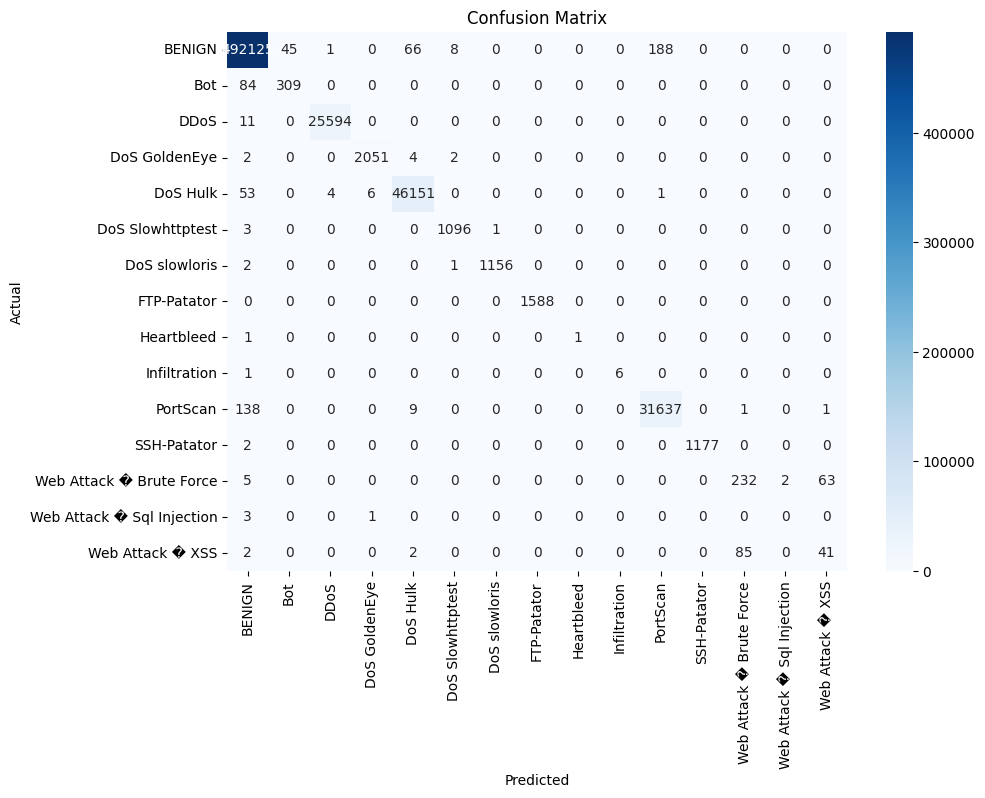

In [10]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 Path to your folder
data_dir = "D:\AISA_Miniproject\FlowGANAnomaly\cicids2017"

# 🔹 Load all CSVs in the folder
dfs = []
for file in os.listdir(data_dir):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(data_dir, file))
        dfs.append(df)

# 🔹 Combine all into one DataFrame
df = pd.concat(dfs, ignore_index=True)

# 🔹 Fix column names (strip spaces)
df.columns = df.columns.str.strip()

# 🔹 Features and labels
X = df.drop(columns=["Label"])
y = df["Label"]

# 🔹 Convert features to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# 🔹 Replace inf/-inf with NaN, then fill missing values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

# 🔹 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 🔹 Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔹 Train Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train_scaled, y_train)

# 🔹 Predictions
y_pred = clf.predict(X_test_scaled)

# 🔹 Evaluation
print("✅ Classification Report:")
print(classification_report(y_test, y_pred))

# 🔹 Confusion Matrix
plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Note: you may need to restart the kernel to use updated packages.


C:\Users\Aarya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [18:05:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    492433
                       Bot       0.93      0.78      0.85       393
                      DDoS       1.00      1.00      1.00     25605
             DoS GoldenEye       1.00      1.00      1.00      2059
                  DoS Hulk       1.00      1.00      1.00     46215
          DoS Slowhttptest       0.99      1.00      0.99      1100
             DoS slowloris       1.00      1.00      1.00      1159
               FTP-Patator       1.00      1.00      1.00      1588
                Heartbleed       1.00      0.50      0.67         2
              Infiltration       1.00      0.86      0.92         7
                  PortScan       0.99      1.00      1.00     31786
               SSH-Patator       1.00      1.00      1.00      1179
  Web Attack � Brute Force       0.75      0.84      0.79       302
Web Attack � Sql Injec

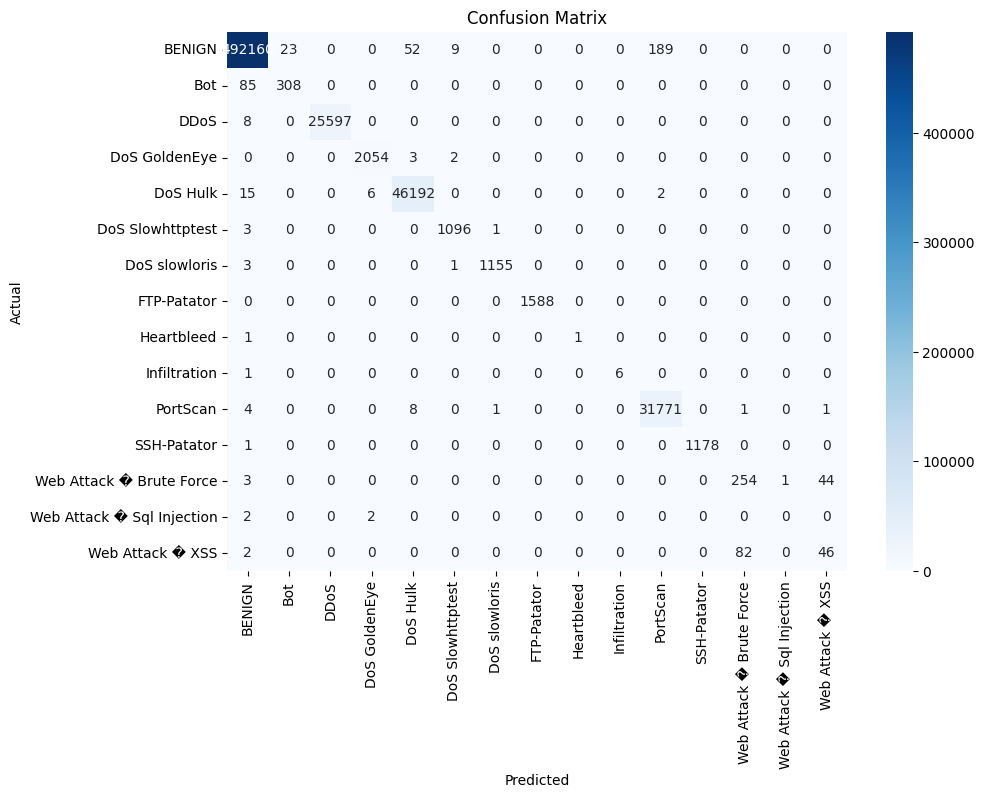

In [44]:
%pip install xgboost
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode labels as integers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=8,
    scale_pos_weight=1,  # can adjust for imbalance
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss"
)
xgb.fit(X_train_scaled, y_train_enc)

# 🔹 Predictions
y_pred_enc = xgb.predict(X_test_scaled)
y_pred = le.inverse_transform(y_pred_enc)

# 🔹 Evaluation
print("✅ Classification Report:")
print(classification_report(y_test, y_pred))

# 🔹 Confusion Matrix
plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Using smote to get better results with rare attack cases like sql injection

In [71]:
import pandas as pd
import glob
import os

# Path to your dataset folder
data_path = "D:/AISA_Miniproject/FlowGANAnomaly/cicids2017"  # e.g. "D:/AISA_Miniproject/CICIDS2017/"

# List all CSV files for training (Mon-Thu, maybe Friday morning if you want)
train_files = glob.glob(os.path.join(data_path, "D:/AISA_Miniproject/FlowGANAnomaly/cicids2017/Monday-WorkingHours.pcap_ISCX.csv")) \
             + glob.glob(os.path.join(data_path, "D:/AISA_Miniproject/FlowGANAnomaly/cicids2017/Tuesday-WorkingHours.pcap_ISCX.csv")) \
             + glob.glob(os.path.join(data_path, "D:/AISA_Miniproject/FlowGANAnomaly/cicids2017/Wednesday-WorkingHours.pcap_ISCX.csv")) \
             + glob.glob(os.path.join(data_path, "D:/AISA_Miniproject/FlowGANAnomaly/cicids2017/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv")) \
             + glob.glob(os.path.join(data_path, "D:/AISA_Miniproject/FlowGANAnomaly/cicids2017/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv"))

print("Training files:", train_files)

# Merge them all
train_df = pd.concat((pd.read_csv(file) for file in train_files), ignore_index=True)
print("Training data shape:", train_df.shape)

# Save merged training file
train_df.to_csv("CICIDS2017_Train.csv", index=False)


Training files: ['D:/AISA_Miniproject/FlowGANAnomaly/cicids2017/Monday-WorkingHours.pcap_ISCX.csv', 'D:/AISA_Miniproject/FlowGANAnomaly/cicids2017/Tuesday-WorkingHours.pcap_ISCX.csv', 'D:/AISA_Miniproject/FlowGANAnomaly/cicids2017/Wednesday-WorkingHours.pcap_ISCX.csv', 'D:/AISA_Miniproject/FlowGANAnomaly/cicids2017/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'D:/AISA_Miniproject/FlowGANAnomaly/cicids2017/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv']
Training data shape: (2127498, 79)


In [72]:
# Collect Friday test files
test_files = (
    glob.glob(os.path.join(data_path, "D:/AISA_Miniproject/FlowGANAnomaly/cicids2017/Friday-WorkingHours-Morning.pcap_ISCX.csv"))
    + glob.glob(os.path.join(data_path, "D:/AISA_Miniproject/FlowGANAnomaly/cicids2017/test_Web_Attack_–_Brute_Force.csv"))
    + glob.glob(os.path.join(data_path, "D:/AISA_Miniproject/FlowGANAnomaly/cicids2017/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv"))
    + glob.glob(os.path.join(data_path, "D:/AISA_Miniproject/FlowGANAnomaly/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"))
)
print("Test files:", test_files)

# Merge them all
test_df = pd.concat((pd.read_csv(file) for file in test_files), ignore_index=True)
print("Test data shape:", test_df.shape)

# Save merged test file
test_df.to_csv("CICIDS2017_Test.csv", index=False)


Test files: ['D:/AISA_Miniproject/FlowGANAnomaly/cicids2017/Friday-WorkingHours-Morning.pcap_ISCX.csv', 'D:/AISA_Miniproject/FlowGANAnomaly/cicids2017/test_Web_Attack_–_Brute_Force.csv', 'D:/AISA_Miniproject/FlowGANAnomaly/cicids2017/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'D:/AISA_Miniproject/FlowGANAnomaly/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv']


C:\Users\Aarya\AppData\Local\Temp\ipykernel_11016\602429845.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  test_df = pd.concat((pd.read_csv(file) for file in test_files), ignore_index=True)


Test data shape: (703245, 79)


In [73]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE


In [74]:
# Load merged training data
train_df = pd.read_csv("CICIDS2017_Train.csv")

# Drop rows with NaN or infinity (optional but recommended)
train_df = train_df.replace([np.inf, -np.inf], np.nan).dropna()

print("Training data shape after cleaning:", train_df.shape)


Training data shape after cleaning: (2125158, 79)


In [75]:
# Features and labels
X = train_df.drop(columns=[" Label"])  
y = train_df[" Label"]

print("Unique classes in training set:", y.unique())


Unique classes in training set: ['BENIGN' 'FTP-Patator' 'SSH-Patator' 'DoS slowloris' 'DoS Slowhttptest'
 'DoS Hulk' 'DoS GoldenEye' 'Heartbleed' 'Web Attack � Brute Force'
 'Web Attack � XSS' 'Web Attack � Sql Injection' 'Infiltration']


In [76]:
# Encode labels (string -> number)
le = LabelEncoder()
y_enc = le.fit_transform(y)

print("Classes mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


Classes mapping: {'BENIGN': np.int64(0), 'DoS GoldenEye': np.int64(1), 'DoS Hulk': np.int64(2), 'DoS Slowhttptest': np.int64(3), 'DoS slowloris': np.int64(4), 'FTP-Patator': np.int64(5), 'Heartbleed': np.int64(6), 'Infiltration': np.int64(7), 'SSH-Patator': np.int64(8), 'Web Attack � Brute Force': np.int64(9), 'Web Attack � Sql Injection': np.int64(10), 'Web Attack � XSS': np.int64(11)}


In [77]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [79]:
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Step 1: Downsample majority class to reduce memory usage
rus = RandomUnderSampler(random_state=42, sampling_strategy={0: 50000})  # 0 is usually 'BENIGN'
X_down, y_down = rus.fit_resample(X_scaled, y_enc)

print("Class distribution after downsampling:", Counter(y_down))

# Step 2: Only oversample rare classes (example: class 4 and 5)
smote = SMOTE(
	random_state=42,
	sampling_strategy={
		4: 6000,   # SQL Injection
		5: 8000,   # Heartbleed
	}
)
X_res, y_res = smote.fit_resample(X_down, y_down)

print("Shape before SMOTE:", X_down.shape, y_down.shape)
print("Shape after SMOTE:", X_res.shape, y_res.shape)
print("Class distribution after SMOTE:", Counter(y_res))


Class distribution after downsampling: Counter({np.int64(2): 230124, np.int64(0): 50000, np.int64(1): 10293, np.int64(5): 7935, np.int64(8): 5897, np.int64(4): 5796, np.int64(3): 5499, np.int64(9): 1507, np.int64(11): 652, np.int64(7): 36, np.int64(10): 21, np.int64(6): 11})
Shape before SMOTE: (317771, 78) (317771,)
Shape after SMOTE: (318040, 78) (318040,)
Class distribution after SMOTE: Counter({np.int64(2): 230124, np.int64(0): 50000, np.int64(1): 10293, np.int64(5): 8000, np.int64(4): 6000, np.int64(8): 5897, np.int64(3): 5499, np.int64(9): 1507, np.int64(11): 652, np.int64(7): 36, np.int64(10): 21, np.int64(6): 11})


In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

print("Train size:", X_train.shape, "Validation size:", X_val.shape)


Train size: (2209190, 78) Validation size: (552298, 78)


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# ------------------------------
# 1. Load merged training dataset
# ------------------------------
df = pd.read_csv("CICIDS2017_Train.csv")
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# Features (X) and target (y)
X = df.drop(columns=[" Label"])
y = df[" Label"]

# ------------------------------
# 2. Encode labels
# ------------------------------
le = LabelEncoder()
y_enc = le.fit_transform(y)

print("Classes mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# ------------------------------
# 3. Scale features
# ------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------
# 4. Downsample majority class before SMOTE
# ------------------------------
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Downsample 'BENIGN' (class 0) to e.g. 50000 samples
rus = RandomUnderSampler(random_state=42, sampling_strategy={0: 50000})
X_down, y_down = rus.fit_resample(X_scaled, y_enc)
print("Class distribution after downsampling:", Counter(y_down))

# ------------------------------
# 5. Apply SMOTE
# ------------------------------
smote = SMOTE(random_state=42, sampling_strategy="auto")
X_res, y_res = smote.fit_resample(X_down, y_down)

print("Before SMOTE:", X_down.shape, y_down.shape)
print("After SMOTE:", X_res.shape, y_res.shape)

# ------------------------------
# 5. Train-test split
# ------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# ------------------------------
# 6. RandomForest Training
# ------------------------------
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_val)

print("\n🌲 RandomForest Results:")
print("Accuracy:", accuracy_score(y_val, y_pred_rf))
print(classification_report(y_val, y_pred_rf, target_names=le.classes_))

# ------------------------------
# 7. XGBoost Training
# ------------------------------
xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss"
)
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_val)

print("\n⚡ XGBoost Results:")
print("Accuracy:", accuracy_score(y_val, y_pred_xgb))
print(classification_report(y_val, y_pred_xgb, target_names=le.classes_))


Classes mapping: {'BENIGN': np.int64(0), 'DoS GoldenEye': np.int64(1), 'DoS Hulk': np.int64(2), 'DoS Slowhttptest': np.int64(3), 'DoS slowloris': np.int64(4), 'FTP-Patator': np.int64(5), 'Heartbleed': np.int64(6), 'Infiltration': np.int64(7), 'SSH-Patator': np.int64(8), 'Web Attack � Brute Force': np.int64(9), 'Web Attack � Sql Injection': np.int64(10), 'Web Attack � XSS': np.int64(11)}
Class distribution after downsampling: Counter({np.int64(2): 230124, np.int64(0): 50000, np.int64(1): 10293, np.int64(5): 7935, np.int64(8): 5897, np.int64(4): 5796, np.int64(3): 5499, np.int64(9): 1507, np.int64(11): 652, np.int64(7): 36, np.int64(10): 21, np.int64(6): 11})
Class distribution after downsampling: Counter({np.int64(2): 230124, np.int64(0): 50000, np.int64(1): 10293, np.int64(5): 7935, np.int64(8): 5897, np.int64(4): 5796, np.int64(3): 5499, np.int64(9): 1507, np.int64(11): 652, np.int64(7): 36, np.int64(10): 21, np.int64(6): 11})
Before SMOTE: (317771, 78) (317771,)
After SMOTE: (2761488

C:\Users\Aarya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [19:01:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



⚡ XGBoost Results:
Accuracy: 0.9859025381225353
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00     46025
             DoS GoldenEye       1.00      1.00      1.00     46025
                  DoS Hulk       1.00      1.00      1.00     46025
          DoS Slowhttptest       1.00      1.00      1.00     46025
             DoS slowloris       1.00      1.00      1.00     46025
               FTP-Patator       1.00      1.00      1.00     46025
                Heartbleed       1.00      1.00      1.00     46025
              Infiltration       1.00      1.00      1.00     46025
               SSH-Patator       1.00      1.00      1.00     46025
  Web Attack � Brute Force       0.94      0.89      0.92     46024
Web Attack � Sql Injection       1.00      1.00      1.00     46024
          Web Attack � XSS       0.90      0.94      0.92     46025

                  accuracy                           0.99    5522

Stacking Model Accuracy: 0.9791815288123441
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     46025
           1       1.00      1.00      1.00     46025
           2       1.00      1.00      1.00     46025
           3       1.00      0.99      1.00     46025
           4       1.00      1.00      1.00     46025
           5       1.00      1.00      1.00     46025
           6       1.00      1.00      1.00     46025
           7       1.00      1.00      1.00     46025
           8       1.00      1.00      1.00     46025
           9       0.90      0.87      0.88     46024
          10       1.00      1.00      1.00     46024
          11       0.87      0.90      0.89     46025

    accuracy                           0.98    552298
   macro avg       0.98      0.98      0.98    552298
weighted avg       0.98      0.98      0.98    552298

              precision    recall  f1-score   support

           0       0.99      0.99 

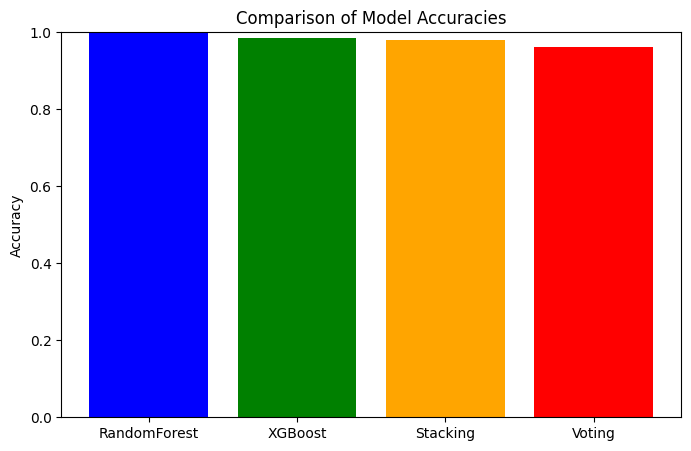

In [16]:
# Hybrid Model 1: Random Forest + Logistic Regression (Stacking)
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Ensure train/val split variables are defined
try:
    X_train
    X_val
    y_train
    y_val
except NameError:
    raise RuntimeError("Please run the cell that defines X_train, X_val, y_train, y_val before running this cell.")

from sklearn.utils import resample

# Downsample for stacking/voting to avoid MemoryError
X_train_small, y_train_small = resample(
    X_train, y_train, 
    n_samples=50000, 
    random_state=42, 
    stratify=y_train
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)

stack_model = StackingClassifier(
    estimators=[('rf', rf)],
    final_estimator=lr,
    cv=5
 )
stack_model.fit(X_train_small, y_train_small)
stack_pred = stack_model.predict(X_val)
stack_acc = accuracy_score(y_val, stack_pred)
print('Stacking Model Accuracy:', stack_acc)
print(classification_report(y_val, stack_pred))

from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

svm = SVC(probability=True, random_state=42)

voting_model = VotingClassifier(
    estimators=[('rf', rf), ('svm', svm), ('lr', lr)],
    voting='soft'
 )
voting_model.fit(X_train_small, y_train_small)
voting_pred = voting_model.predict(X_val)
voting_acc = accuracy_score(y_val, voting_pred)
print('Voting Classifier Accuracy:', voting_acc)
print(classification_report(y_val, voting_pred))

# Compare all models: RandomForest, XGBoost, Stacking, Voting
import matplotlib.pyplot as plt
labels = ['RandomForest', 'XGBoost', 'Stacking', 'Voting']
accuracies = [accuracy_score(y_val, y_pred_rf), accuracy_score(y_val, y_pred_xgb), stack_acc, voting_acc]
plt.figure(figsize=(8,5))
plt.bar(labels, accuracies, color=['blue', 'green', 'orange', 'red'])
plt.ylabel('Accuracy')
plt.title('Comparison of Model Accuracies')
plt.ylim(0.0, 1.0)
plt.show()